In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

In [4]:
df = pd.read_parquet(r"C:\cinemind\src\data\analytics\development_tmdb.parquet")
df

,source,source_id,title,original_title,alternative_titles,media_type,source_media_type,release_date,release_year,end_date,...,status,runtime,num_episodes,source_material,discovered_from,tmdb_id,mal_id,cinemind_id,source_presence,match_confidence
0,tmdb,1264620,Lohengrin,Lohengrin,[],movie,movie,1909-01-27,1909.0,NaN,...,NaN,NaN,NaN,NaN,[year_lang],1264620,<NA>,cinemind_tmdb_1264620,[tmdb],unmatched
1,tmdb,1451635,Gutenberg-Feier in Mainz,Gutenberg-Feier in Mainz,[],movie,movie,1900-01-01,1900.0,NaN,...,NaN,NaN,NaN,NaN,[year],1451635,<NA>,cinemind_tmdb_1451635,[tmdb],unmatched
2,tmdb,1673699,How Farmer Klaus Was Cured of His Illness,Wie Bauer Klaus von seiner Krankheit geheilt w...,[],movie,movie,1906-01-01,1906.0,NaN,...,NaN,NaN,NaN,NaN,[year],1673699,<NA>,cinemind_tmdb_1673699,[tmdb],unmatched
3,tmdb,417847,A Trip Through Vienna,Eine Fahrt durch Wien,[],movie,movie,1906-09-24,1906.0,NaN,...,NaN,NaN,NaN,NaN,[year],417847,<NA>,cinemind_tmdb_417847,[tmdb],unmatched
4,tmdb,1311009,Julius Neubronner zaubert,Julius Neubronner zaubert,[],movie,movie,1904-06-11,1904.0,NaN,...,NaN,NaN,NaN,NaN,[year],1311009,<NA>,cinemind_tmdb_1311009,[tmdb],unmatched
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81421,tmdb+mal,223523,6HP - Six Hearts Princess,6HP(シックスハートプリンセス),[],tv_special,tv,2016-12-30,2016.0,NaN,...,NaN,NaN,NaN,NaN,[year_lang],223523,29643,cinemind_tmdb_223523_mal_29643,"[tmdb, mal]",medium
81422,tmdb+mal,70468,The Dragon Dentist,龍の歯医者,[],tv_special,tv,2017-02-18,2017.0,NaN,...,NaN,NaN,NaN,NaN,[year_lang],70468,34549,cinemind_tmdb_70468_mal_34549,"[tmdb, mal]",medium
81423,tmdb+mal,113041,"Phoenix: ""Dougo Onsen"" Chapter",火の鳥 道後温泉編,[],cm,tv,2019-05-24,2019.0,NaN,...,NaN,NaN,NaN,NaN,[year_lang],113041,39663,cinemind_tmdb_113041_mal_39663,"[tmdb, mal]",medium
81424,tmdb+mal,262301,Science SARU x MBS Original Short Anime Daisak...,サイエンスSARU×MBS オリジナルショートアニメ大作戦！,[],tv_special,tv,2024-03-01,2024.0,NaN,...,NaN,NaN,NaN,NaN,[year_lang],262301,58006,cinemind_tmdb_262301_mal_58006,"[tmdb, mal]",medium


In [5]:
df.shape

(81426, 33)

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 81426 entries, 0 to 81425
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   source                81426 non-null  str    
 1   source_id             81426 non-null  int64  
 2   title                 81426 non-null  str    
 3   original_title        81426 non-null  str    
 4   alternative_titles    81426 non-null  object 
 5   media_type            81426 non-null  str    
 6   source_media_type     81426 non-null  str    
 7   release_date          81426 non-null  str    
 8   release_year          81426 non-null  float64
 9   end_date              0 non-null      str    
 10  genres                81426 non-null  object 
 11  original_language     81426 non-null  str    
 12  origin_country        81426 non-null  object 
 13  overview              81426 non-null  str    
 14  rating                81426 non-null  float64
 15  vote_count            81426 no

In [7]:
null = df.isna().sum()
null[null > 0]

end_date           81426
rank               81426
favorites          81426
num_list_users     81426
status             81426
runtime            81426
num_episodes       81426
source_material    81426
mal_id             74973
dtype: int64

In [8]:
null_cols = null[null > 0].index.tolist()
null_cols

['end_date',
 'rank',
 'favorites',
 'num_list_users',
 'status',
 'runtime',
 'num_episodes',
 'source_material',
 'mal_id']

In [13]:
df.loc[:, ['media_type', *null_cols]]['media_type'].value_counts()

media_type
movie          45656
tv             29317
anime_tv        2695
anime_movie     1954
ova              952
ona              480
tv_special       176
special          145
music             42
cm                 5
pv                 4
Name: count, dtype: int64

In [30]:
for val in df['media_type'].unique().tolist():
    print(f"{val}: {df.loc[df['media_type'] == 'movie'][null_cols].shape[0]}")

movie: 45656
tv: 45656
anime_movie: 45656
special: 45656
anime_tv: 45656
ova: 45656
music: 45656
ona: 45656
tv_special: 45656
cm: 45656
pv: 45656


In [32]:
?pd.pivot_table

Signature:
pd.pivot_table(
    data: 'DataFrame',
    values=None,
    index=None,
    columns=None,
    aggfunc: 'AggFuncType' = 'mean',
    fill_value=None,
    margins: 'bool' = False,
    dropna: 'bool' = True,
    margins_name: 'Hashable' = 'All',
    observed: 'bool' = True,
    sort: 'bool' = True,
    **kwargs,
) -> 'DataFrame'
Docstring:
Create a spreadsheet-style pivot table as a DataFrame.

The levels in the pivot table will be stored in MultiIndex objects
(hierarchical indexes) on the index and columns of the result DataFrame.

Parameters
----------
data : DataFrame
    Input pandas DataFrame object.
values : list-like or scalar, optional
    Column or columns to aggregate.
index : column, Grouper, array, or sequence of the previous
    Keys to group by on the pivot table index. If a list is passed,
    it can contain any of the other types (except list). If an array is
    passed, it must be the same length as the data and will be used in
    the same manner as column valu

In [35]:
pd.pivot_table(data = df, index = df['media_type'], values = null_cols, aggfunc='count')

,end_date,favorites,mal_id,num_episodes,num_list_users,rank,runtime,source_material,status
media_type,,,,,,,,,
anime_movie,0,0,1954,0,0,0,0,0,0
anime_tv,0,0,2695,0,0,0,0,0,0
cm,0,0,5,0,0,0,0,0,0
movie,0,0,0,0,0,0,0,0,0
music,0,0,42,0,0,0,0,0,0
ona,0,0,480,0,0,0,0,0,0
ova,0,0,952,0,0,0,0,0,0
pv,0,0,4,0,0,0,0,0,0
special,0,0,145,0,0,0,0,0,0


In [36]:
df['genres']

0                                                  [Drama]
1                                            [Documentary]
2                                                 [Comedy]
3                                            [Documentary]
4                                            [Documentary]
                               ...                        
81421                                          [Animation]
81422    [Animation, Action & Adventure, Sci-Fi & Fantasy]
81423                                                   []
81424                                          [Animation]
81425                                  [Animation, Comedy]
Name: genres, Length: 81426, dtype: object

In [39]:
df.explode('genres')['genres'].value_counts()

genres
Drama                 27340
Comedy                15778
Documentary           10467
Animation              9781
Crime                  4405
Romance                4163
Family                 4145
Action                 3474
Mystery                3006
Action & Adventure     2937
Sci-Fi & Fantasy       2549
Reality                2406
Adventure              2396
Thriller               2325
Horror                 2192
Fantasy                2024
Music                  2023
Kids                   1596
Science Fiction        1518
History                1432
TV Movie               1381
Soap                   1145
Talk                   1128
War                    1087
Western                 792
War & Politics          648
News                    396
Name: count, dtype: int64

In [41]:
temp = df.copy()
temp['title'] = temp['genres'].str.join('+')
temp['title']

0                                                Drama
1                                          Documentary
2                                               Comedy
3                                          Documentary
4                                          Documentary
                             ...                      
81421                                        Animation
81422    Animation+Action & Adventure+Sci-Fi & Fantasy
81423                                                 
81424                                        Animation
81425                                 Animation+Comedy
Name: title, Length: 81426, dtype: object

In [48]:
res = dict()
for ind in temp['title'].value_counts().index:
    res[ind] = temp['title'].value_counts()[ind]

res

{'': np.int64(14254),
 'Drama': np.int64(12213),
 'Documentary': np.int64(8550),
 'Comedy': np.int64(6061),
 'Animation': np.int64(2505),
 'Reality': np.int64(1694),
 'Comedy+Drama': np.int64(1032),
 'Drama+Romance': np.int64(998),
 'Drama+Comedy': np.int64(901),
 'Animation+Comedy': np.int64(773),
 'Horror': np.int64(724),
 'Talk': np.int64(627),
 'Music': np.int64(602),
 'Drama+Crime': np.int64(552),
 'Crime': np.int64(487),
 'Crime+Drama': np.int64(487),
 'Romance': np.int64(457),
 'Family': np.int64(444),
 'Drama+Family': np.int64(436),
 'Action': np.int64(404),
 'Romance+Drama': np.int64(365),
 'Soap+Drama': np.int64(354),
 'Comedy+Romance': np.int64(340),
 'Drama+History': np.int64(323),
 'Western': np.int64(305),
 'Animation+Action & Adventure+Sci-Fi & Fantasy': np.int64(296),
 'Animation+Kids': np.int64(288),
 'Drama+Soap': np.int64(286),
 'Drama+Mystery': np.int64(279),
 'Mystery': np.int64(272),
 'Thriller': np.int64(268),
 'Comedy+Family': np.int64(261),
 'Drama+TV Movie': n

In [51]:
exploded = df.explode('genres')
pivot = pd.pivot_table(data=exploded,index='media_type',columns='genres',values='cinemind_id',aggfunc='count',fill_value=0)
pivot

genres,Action,Action & Adventure,Adventure,Animation,Comedy,Crime,Documentary,Drama,Family,Fantasy,...,Romance,Sci-Fi & Fantasy,Science Fiction,Soap,TV Movie,Talk,Thriller,War,War & Politics,Western
media_type,,,,,,,,,,,,,,,,,,,,,
anime_movie,404,1,379,1908,316,26,7,384,263,479,...,127,4,366,0,12,0,25,55,1,3
anime_tv,30,986,21,2583,1167,51,2,663,110,24,...,29,1106,14,1,1,0,7,0,36,5
cm,0,0,1,3,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
movie,2743,0,1824,2135,8768,2356,6828,16397,1557,1334,...,3872,0,878,0,1295,0,2270,1010,0,669
music,3,3,1,32,4,2,0,9,1,2,...,0,2,4,0,1,0,0,0,0,0
ona,21,195,12,463,123,10,0,101,11,24,...,8,199,18,0,1,0,1,3,7,0
ova,203,113,97,905,260,36,1,171,17,122,...,78,134,184,0,4,0,19,13,12,2
pv,0,0,0,4,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
special,24,6,19,136,49,5,0,22,5,14,...,9,10,27,0,4,0,0,0,0,0


In [60]:
ct = pd.crosstab(df['media_type'], df['original_language'])
dominant_summary = pd.DataFrame({
    'dominant_language': ct.idxmax(axis=1),
    'dominant_count': ct.max(axis=1),
    'total_count': ct.sum(axis=1),
    'share_pct': (ct.max(axis=1) / ct.sum(axis=1) * 100).round(2)
})
dominant_summary

,dominant_language,dominant_count,total_count,share_pct
media_type,,,,
anime_movie,ja,1550,1954,79.32
anime_tv,ja,2501,2695,92.80
cm,ja,5,5,100.00
movie,en,5193,45656,11.37
music,ja,33,42,78.57
ona,zh,233,480,48.54
ova,ja,933,952,98.00
pv,ja,2,4,50.00
special,ja,139,145,95.86


In [ ]:
exploded_country = df.explode('origin_country').reset_index(drop=True)
ct_country = pd.crosstab(exploded_country['media_type'], exploded_country['origin_country'])

In [65]:
dominant_country_summary = pd.DataFrame({
    'dominant_country': ct_country.idxmax(axis=1),
    'dominant_count': ct_country.max(axis=1),
    'total_count': ct_country.sum(axis=1),
    'share_pct': (ct_country.max(axis=1) / ct_country.sum(axis=1) * 100).round(2)
})
dominant_country_summary

,dominant_country,dominant_count,total_count,share_pct
media_type,,,,
anime_movie,JP,9,9,100.00
anime_tv,JP,2397,2617,91.59
cm,JP,1,1,100.00
music,JP,5,7,71.43
ona,CN,219,405,54.07
ova,JP,308,323,95.36
special,JP,42,43,97.67
tv,DE,2398,28487,8.42
tv_special,JP,15,16,93.75


In [67]:
def is_country_missing(val):
    if val is None:
        return True
    if hasattr(val, '__len__'):
        return len(val) == 0
    return False

df['is_missing_country'] = df['origin_country'].apply(is_country_missing)
missing_country_summary = df.groupby('media_type')['is_missing_country'].agg(
    missing_count='sum',
    total_records='count',
    missing_pct=lambda s: round(s.mean() * 100, 2)
)
missing_country_summary

,missing_count,total_records,missing_pct
media_type,,,
anime_movie,1945,1954,99.54
anime_tv,122,2695,4.53
cm,4,5,80.00
movie,45656,45656,100.00
music,35,42,83.33
ona,83,480,17.29
ova,631,952,66.28
pv,4,4,100.00
special,102,145,70.34


In [70]:
df['release_date'] = pd.to_datetime(df['release_date'], format='%Y-%m-%d', errors='coerce')

In [71]:
df['release_year'] = df['release_date'].dt.year
df['release_year']

0        1909
1        1900
2        1906
3        1906
4        1904
         ... 
81421    2016
81422    2017
81423    2019
81424    2024
81425    2015
Name: release_year, Length: 81426, dtype: int32

In [74]:
pd.pivot_table(data = df, index = 'media_type', columns = 'release_year', aggfunc='count', fill_value=0)

alternative_titles                                               \
release_year               1900 1901 1902 1903 1904 1905 1906 1907 1908 1909   
media_type                                                                     
anime_movie                   0    0    0    0    0    0    0    0    0    0   
anime_tv                      0    0    0    0    0    0    0    0    0    0   
cm                            0    0    0    0    0    0    0    0    0    0   
movie                        88   61   57   76   67   68   85   84  143  187   
music                         0    0    0    0    0    0    0    0    0    0   
ona                           0    0    0    0    0    0    0    0    0    0   
ova                           0    0    0    0    0    0    0    0    0    0   
pv                            0    0    0    0    0    0    0    0    0    0   
special                       0    0    0    0    0    0    0    0    0    0   
tv                            0    0    0    0    0    0    0    0    0    0   
tv_special                    0    0    0    0    0    0    0    0    0    0   

              ... vote_count                                                 \
release_year  ...       2017 2018  2019  2020  2021  2022  2023  2024  2025   
media_type    ...                                                             
anime_movie   ...         42   51    59    38    42    40    42    40    45   
anime_tv      ...        114  108    85    91   125    94   120   115   103   
cm            ...          1    0     1     0     0     1     0     0     0   
movie         ...        626  642   676   710   766   778   854   801   850   
music         ...          0    0     0     0     1     4     1     2     2   
ona           ...         25   40    28    43    37    47    59    40    35   
ova           ...          6    4     4     5    11     4     6     0     2   
pv            ...          0    0     0     0     0     1     0     0     0   
special       ...          0    4     3     0     2     1     3     1     1   
tv            ...        858  877  1038  1064  1361  1245  1134  1102  1020   
tv_special    ...          3    3     2     0     2     1     2     1     2   

                   
release_year 2026  
media_type         
anime_movie    33  
anime_tv       90  
cm              0  
movie         713  
music           0  
ona            25  
ova             1  
pv              0  
special         0  
tv            844  
tv_special      2  

[11 rows x 4064 columns]

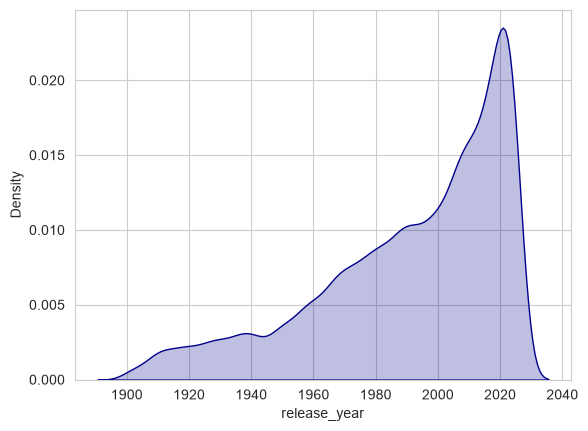

In [77]:
sns.kdeplot(df['release_year'], fill = True, color='darkblue')
plt.show()

In [78]:
features = [
    'media_type',
    'genres',
    'original_language',
    'origin_country',
    'release_year',
    'runtime',
    'num_episodes',
    'status',
    'source_material'
]

results = []

for feature in features:
    if feature in ['genres', 'origin_country']:
        temp = df[[feature]].dropna().copy()
        values = temp[feature].explode()
        counts = values.value_counts()

        if len(counts) > 1:
            proportions = counts / counts.sum()
            entropy = -(proportions * np.log2(proportions)).sum()
            top_share = proportions.iloc[0]

            results.append({
                'feature': feature,
                'unique_values': len(counts),
                'top_value_share': round(top_share, 3),
                'entropy': round(entropy, 3)
            })

    else:
        temp = df[feature].dropna()
        counts = temp.value_counts()

        if len(counts) > 1:
            proportions = counts / counts.sum()
            entropy = -(proportions * np.log2(proportions)).sum()
            top_share = proportions.iloc[0]

            results.append({
                'feature': feature,
                'unique_values': len(counts),
                'top_value_share': round(top_share, 3),
                'entropy': round(entropy, 3)
            })

feature_analysis = pd.DataFrame(results)
feature_analysis.sort_values(
    'entropy',
    ascending=False
)

,feature,unique_values,top_value_share,entropy
4,release_year,127,0.029,6.528
3,origin_country,117,0.162,4.760
2,original_language,94,0.137,4.253
1,genres,27,0.243,3.929
0,media_type,11,0.561,1.452


In [82]:
yes = (df['media_type'] == 'movie').sum()
no = len(df) - yes
print("Movie:")
print("YES:", yes, f"({yes/len(df)*100:.2f}%)")
print("NO :", no,  f"({no/len(df)*100:.2f}%)")

yes = (df['media_type'] == 'tv').sum()
no = len(df) - yes
print("\nTV:")
print("YES:", yes, f"({yes/len(df)*100:.2f}%)")
print("NO :", no,  f"({no/len(df)*100:.2f}%)")

anime_types = [
    'anime_tv',
    'anime_movie',
    'ova',
    'ona',
    'special',
    'tv_special',
    'pv',
    'cm'
]
yes = df['media_type'].isin(anime_types).sum()
no = len(df) - yes
print("\nAnime:")
print("YES:", yes, f"({yes/len(df)*100:.2f}%)")
print("NO :", no,  f"({no/len(df)*100:.2f}%)")

Movie:
YES: 45656 (56.07%)
NO : 35770 (43.93%)

TV:
YES: 29317 (36.00%)
NO : 52109 (64.00%)

Anime:
YES: 6411 (7.87%)
NO : 75015 (92.13%)


In [85]:
for col in exploded['genres'].dropna().unique():
    yes = (exploded['genres'] == col).sum()
    no = len(df) - yes 
    print(f"\n{col}:")
    print("YES:", yes, f"({yes/len(df)*100:.2f}%)")
    print("NO :", no,  f"({no/len(df)*100:.2f}%)")


Drama:
YES: 27340 (33.58%)
NO : 54086 (66.42%)

Documentary:
YES: 10467 (12.85%)
NO : 70959 (87.15%)

Comedy:
YES: 15778 (19.38%)
NO : 65648 (80.62%)

Music:
YES: 2023 (2.48%)
NO : 79403 (97.52%)

Adventure:
YES: 2396 (2.94%)
NO : 79030 (97.06%)

Crime:
YES: 4405 (5.41%)
NO : 77021 (94.59%)

Romance:
YES: 4163 (5.11%)
NO : 77263 (94.89%)

Fantasy:
YES: 2024 (2.49%)
NO : 79402 (97.51%)

Action:
YES: 3474 (4.27%)
NO : 77952 (95.73%)

History:
YES: 1432 (1.76%)
NO : 79994 (98.24%)

War:
YES: 1087 (1.33%)
NO : 80339 (98.67%)

Western:
YES: 792 (0.97%)
NO : 80634 (99.03%)

Animation:
YES: 9781 (12.01%)
NO : 71645 (87.99%)

Horror:
YES: 2192 (2.69%)
NO : 79234 (97.31%)

Thriller:
YES: 2325 (2.86%)
NO : 79101 (97.14%)

Family:
YES: 4145 (5.09%)
NO : 77281 (94.91%)

Science Fiction:
YES: 1518 (1.86%)
NO : 79908 (98.14%)

Mystery:
YES: 3006 (3.69%)
NO : 78420 (96.31%)

TV Movie:
YES: 1381 (1.70%)
NO : 80045 (98.30%)

Reality:
YES: 2406 (2.95%)
NO : 79020 (97.05%)

Talk:
YES: 1128 (1.39%)
NO : 

In [88]:
N = len(df)

for col in exploded['genres'].dropna().unique():
    yes = (exploded['genres'] == col).sum()
    no = N - yes
    p_yes = yes / N
    p_no = no / N

    entropy_before = np.log2(N)
    entropy_after = (
        p_yes * np.log2(yes) +
        p_no * np.log2(no)
    )
    info_gain = entropy_before - entropy_after

    print(f"\n{col}:")
    print(f"YES: {yes} ({p_yes:.2%})")
    print(f"NO : {no} ({p_no:.2%})")
    print(f"Information Gain: {info_gain:.6f}")


Drama:
YES: 27340 (33.58%)
NO : 54086 (66.42%)
Information Gain: 0.920708

Documentary:
YES: 10467 (12.85%)
NO : 70959 (87.15%)
Information Gain: 0.553438

Comedy:
YES: 15778 (19.38%)
NO : 65648 (80.62%)
Information Gain: 0.709294

Music:
YES: 2023 (2.48%)
NO : 79403 (97.52%)
Information Gain: 0.167839

Adventure:
YES: 2396 (2.94%)
NO : 79030 (97.06%)
Information Gain: 0.191502

Crime:
YES: 4405 (5.41%)
NO : 77021 (94.59%)
Information Gain: 0.303557

Romance:
YES: 4163 (5.11%)
NO : 77263 (94.89%)
Information Gain: 0.291162

Fantasy:
YES: 2024 (2.49%)
NO : 79402 (97.51%)
Information Gain: 0.167904

Action:
YES: 3474 (4.27%)
NO : 77952 (95.73%)
Information Gain: 0.254378

History:
YES: 1432 (1.76%)
NO : 79994 (98.24%)
Information Gain: 0.127666

War:
YES: 1087 (1.33%)
NO : 80339 (98.67%)
Information Gain: 0.102259

Western:
YES: 792 (0.97%)
NO : 80634 (99.03%)
Information Gain: 0.078975

Animation:
YES: 9781 (12.01%)
NO : 71645 (87.99%)
Information Gain: 0.529710

Horror:
YES: 2192 (2.6

In [89]:
for col in df['media_type'].dropna().unique():
    yes = (df['media_type'] == col).sum()
    no = N - yes
    p_yes = yes / N
    p_no = no / N

    entropy_before = np.log2(N)
    entropy_after = (
        p_yes * np.log2(yes) +
        p_no * np.log2(no)
    )
    info_gain = entropy_before - entropy_after

    print(f"\n{col}:")
    print(f"YES: {yes} ({p_yes:.2%})")
    print(f"NO : {no} ({p_no:.2%})")
    print(f"Information Gain: {info_gain:.6f}")


movie:
YES: 45656 (56.07%)
NO : 35770 (43.93%)
Information Gain: 0.989341

tv:
YES: 29317 (36.00%)
NO : 52109 (64.00%)
Information Gain: 0.942720

anime_movie:
YES: 1954 (2.40%)
NO : 79472 (97.60%)
Information Gain: 0.163331

special:
YES: 145 (0.18%)
NO : 81281 (99.82%)
Information Gain: 0.018831

anime_tv:
YES: 2695 (3.31%)
NO : 78731 (96.69%)
Information Gain: 0.209696

ova:
YES: 952 (1.17%)
NO : 80474 (98.83%)
Information Gain: 0.091810

music:
YES: 42 (0.05%)
NO : 81384 (99.95%)
Information Gain: 0.006377

ona:
YES: 480 (0.59%)
NO : 80946 (99.41%)
Information Gain: 0.052139

tv_special:
YES: 176 (0.22%)
NO : 81250 (99.78%)
Information Gain: 0.022252

cm:
YES: 5 (0.01%)
NO : 81421 (99.99%)
Information Gain: 0.000948

pv:
YES: 4 (0.00%)
NO : 81422 (100.00%)
Information Gain: 0.000774


In [90]:
for col in df['original_language'].dropna().unique():
    yes = (df['original_language'] == col).sum()
    no = N - yes
    p_yes = yes / N
    p_no = no / N

    entropy_before = np.log2(N)
    entropy_after = (
        p_yes * np.log2(yes) +
        p_no * np.log2(no)
    )
    info_gain = entropy_before - entropy_after

    print(f"\n{col}:")
    print(f"YES: {yes} ({p_yes:.2%})")
    print(f"NO : {no} ({p_no:.2%})")
    print(f"Information Gain: {info_gain:.6f}")


de:
YES: 6632 (8.14%)
NO : 74794 (91.86%)
Information Gain: 0.407262

en:
YES: 8806 (10.81%)
NO : 72620 (89.19%)
Information Gain: 0.494302

es:
YES: 5616 (6.90%)
NO : 75810 (93.10%)
Information Gain: 0.362070

fr:
YES: 6138 (7.54%)
NO : 75288 (92.46%)
Information Gain: 0.385692

it:
YES: 4221 (5.18%)
NO : 77205 (94.82%)
Information Gain: 0.294156

ja:
YES: 11146 (13.69%)
NO : 70280 (86.31%)
Information Gain: 0.576022

nl:
YES: 3110 (3.82%)
NO : 78316 (96.18%)
Information Gain: 0.233950

cs:
YES: 316 (0.39%)
NO : 81110 (99.61%)
Information Gain: 0.036671

xx:
YES: 232 (0.28%)
NO : 81194 (99.72%)
Information Gain: 0.028195

da:
YES: 934 (1.15%)
NO : 80492 (98.85%)
Information Gain: 0.090391

mk:
YES: 9 (0.01%)
NO : 81417 (99.99%)
Information Gain: 0.001612

no:
YES: 473 (0.58%)
NO : 80953 (99.42%)
Information Gain: 0.051502

pl:
YES: 872 (1.07%)
NO : 80554 (98.93%)
Information Gain: 0.085458

hu:
YES: 136 (0.17%)
NO : 81290 (99.83%)
Information Gain: 0.017817

fa:
YES: 49 (0.06%)
NO : 

In [93]:
anime_types = [
    'anime_tv',
    'anime_movie',
    'ova',
    'ona',
    'special',
    'tv_special',
    'music',
    'cm',
    'pv'
]

anime_df = df[df['media_type'].isin(anime_types)].copy()

print("Total Anime records:", len(anime_df))
print(
    anime_df['media_type']
    .value_counts()
)
language_profile = (
    anime_df['original_language']
    .value_counts()
    .rename_axis('language')
    .reset_index(name='count')
)

language_profile['probability'] = (
    language_profile['count'] / len(anime_df)
)

print(language_profile)
country_profile = (
    anime_df['origin_country']
    .explode()
    .value_counts()
    .rename_axis('country')
    .reset_index(name='count')
)

country_profile['probability'] = (
    country_profile['count'] / len(anime_df)
)

print(country_profile)
genre_profile = (
    anime_df['genres']
    .explode()
    .value_counts()
    .rename_axis('genre')
    .reset_index(name='count')
)

genre_profile['probability'] = (
    genre_profile['count'] / len(anime_df)
)

print(genre_profile)
print("LANGUAGE")
print(language_profile)

print("\nCOUNTRY")
print(country_profile)

print("\nGENRE")
print(genre_profile)

Total Anime records: 6453
media_type
anime_tv       2695
anime_movie    1954
ova             952
ona             480
tv_special      176
special         145
music            42
cm                5
pv                4
Name: count, dtype: int64
   language  count  probability
0        ja   5557     0.861150
1        zh    621     0.096234
2        ko    202     0.031303
3        en     33     0.005114
4        fr      8     0.001240
5        ru      6     0.000930
6        xx      5     0.000775
7        nl      5     0.000775
8        pt      2     0.000310
9        it      2     0.000310
10       es      2     0.000310
11       pl      2     0.000310
12       cn      2     0.000310
13       ar      2     0.000310
14       hr      1     0.000155
15       tl      1     0.000155
16       da      1     0.000155
17       fi      1     0.000155
   country  count  probability
0       JP   2939     0.455447
1       CN    345     0.053464
2       KR     81     0.012552
3       US     24     0.0

In [98]:
df["is_anime"] = df["media_type"].isin([
    "anime_tv",
    "anime_movie",
    "ova",
    "ona",
    "tv_special",
    "special",
    "music",
    "cm",
    "pv"
]).astype(int)

year_analysis = (
    df.groupby("release_year")["is_anime"]
      .agg(["count", "sum", "mean"])
      .reset_index()
)

year_analysis.columns = [
    "release_year",
    "total_count",
    "anime_count",
    "anime_probability"
]

year_analysis["anime_probability"] *= 100
display(year_analysis)

bins = [0, 1950, 1970, 1990, 2000, 2010, 2020, 2026]

labels = [
    "Before 1950",
    "1950-1969",
    "1970-1989",
    "1990-1999",
    "2000-2009",
    "2010-2019",
    "2020-2026"
]

df["year_bin"] = pd.cut(
    df["release_year"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

,release_year,total_count,anime_count,anime_probability
0,1900,88,0,0.000000
1,1901,61,0,0.000000
2,1902,57,0,0.000000
3,1903,76,0,0.000000
4,1904,67,0,0.000000
...,...,...,...,...
122,2022,2216,193,8.709386
123,2023,2221,233,10.490770
124,2024,2102,199,9.467174
125,2025,2060,190,9.223301


In [97]:
p_anime = df["is_anime"].mean()
p_not_anime = 1 - p_anime

root_entropy = -(
    p_anime * np.log2(p_anime) +
    p_not_anime * np.log2(p_not_anime)
)

print("Root Entropy:", root_entropy)

weighted_entropy = 0

for year_bin, group in df.groupby("year_bin", observed=True):
    p_anime = group["is_anime"].mean()
    p_not_anime = 1 - p_anime

    if p_anime == 0 or p_not_anime == 0:
        entropy = 0
    else:
        entropy = -(
            p_anime * np.log2(p_anime) +
            p_not_anime * np.log2(p_not_anime)
        )

    weight = len(group) / len(df)
    weighted_entropy += weight * entropy

    print(
        f"{year_bin}: "
        f"n={len(group)}, "
        f"anime={group['is_anime'].sum()}, "
        f"entropy={entropy:.6f}"
    )

information_gain = root_entropy - weighted_entropy
print("\nWeighted Entropy:", weighted_entropy)
print("Information Gain:", information_gain)

Root Entropy: 0.39953053364187197
Before 1950: n=9788, anime=145, entropy=0.111236
1950-1969: n=8985, anime=211, entropy=0.160577
1970-1989: n=14460, anime=1073, entropy=0.381422
1990-1999: n=8628, anime=900, entropy=0.482516
2000-2009: n=11403, anime=1176, entropy=0.478842
2010-2019: n=15508, anime=1762, entropy=0.510736
2020-2026: n=12654, anime=1186, entropy=0.448784

Weighted Entropy: 0.38402611276488796
Information Gain: 0.015504420876984004
